In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [33]:
def load_data(data_dir, img_size=(28, 28)):
    images = []
    labels = []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)

        if not os.path.isdir(label_path):
            continue

        for file in os.listdir(label_path):
            img_path = os.path.join(label_path, file)

            try:
                img = Image.open(img_path).convert('L')
                img = img.resize(img_size)
                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(int(label.split('_')[1]))  # ✅ FIXED

            except Exception as e:
                print("Error:", e)

    return np.array(images), np.array(labels)

In [21]:
train_dir = "/Users/shreetu/Documents/AI/W4/DevanagariHandwrittenDigitDataset/train"
test_dir = "/Users/shreetu/Documents/AI/W4/DevanagariHandwrittenDigitDataset/test"

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (17000, 28, 28)
Test shape: (3000, 28, 28)


In [22]:
# Flatten images for FCN
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [23]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
 62/107 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - accuracy: 0.9484 - loss: 0.1619

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9546 - loss: 0.1466 - val_accuracy: 0.0000e+00 - val_loss: 13.0084
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - accuracy: 0.9715 - loss: 0.0943 - val_accuracy: 0.0000e+00 - val_loss: 14.2605
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.9840 - loss: 0.0550 - val_accuracy: 0.0000e+00 - val_loss: 14.1670
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.9894 - loss: 0.0381 - val_accuracy: 0.0000e+00 - val_loss: 16.1680
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.9919 - loss: 0.0279 - val_accuracy: 0.0000e+00 - val_loss: 16.2910
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.9936 - loss: 0.0240 - val_accuracy: 0.0000e+00 - val_loss: 17.3071


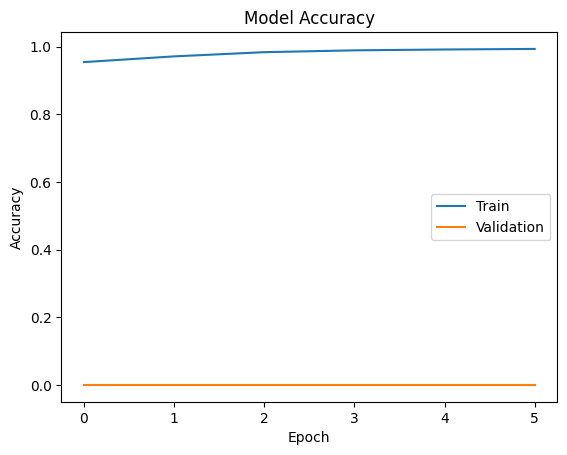

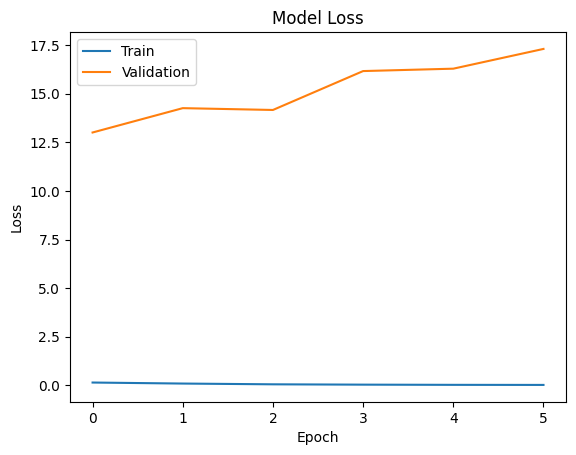

In [27]:
# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [28]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 434us/step - accuracy: 0.7580 - loss: 2.7524
Test Accuracy: 0.7580000162124634
Test Loss: 2.7524421215057373


In [29]:
# Save model
model.save("devnagari_fcn.h5")

# Load model
loaded_model = load_model("devnagari_fcn.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.7580 - loss: 2.7524
Loaded Model Accuracy: 0.7580000162124634


In [30]:
predictions = loaded_model.predict(X_test)

# Convert probabilities to labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:   ", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step
Predicted: [5 2 2 2 2 2 2 2 2 2]
Actual:    [2 2 2 2 2 2 2 2 2 2]
